<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologias Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Linea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibague-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingenieria</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingenieria de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab -- 02 Preprocessing, Cropping & Metadata</div>

# 02 -- Preprocessing, YOLO Cropping & Metadata

Pipeline completo de preprocesamiento con clasificacion en **tres estados** por imagen.

### Logica de clasificacion

```
imagen raw
    |
    v
[YOLO] -- sin deteccion ------------> REJECTED  (no_detection)
    |
    v
[Umbrales DUROS]
    conf < 0.30  o  area < 0.02 -----> REJECTED  (hard thresholds)
    |
    v
[Margen dinamico + Clip a bordes]
    bbox vacio tras clip ------------> REJECTED  (bbox_empty_after_clip)
    |
    v
[Metricas] conf, area, touches_edge,
           aspect_ratio, clipped, final_size
    |
    v
[Umbrales BLANDOS] -- alguno falla --> NEEDS_REVIEW  (flags detallados)
    |
    v
ACCEPTED
```

### Destinos en disco

| Estado | Carpeta |
|--------|---------|
| ACCEPTED | `data/processed/<clase>/` |
| NEEDS_REVIEW | `data/review/<clase>/` |
| REJECTED | solo metadata.sqlite |

### Metadatos

Cada imagen queda registrada en `metadata/metadata.sqlite` con:
`image, class, status, confidence, bbox_area_ratio, touches_edge,`
`clipped, aspect_ratio, final_w, final_h, rejection_reason, review_flags`


## 1. Entorno y configuracion

In [1]:
import sys
from pathlib import Path
from collections import defaultdict, Counter
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print("Configuracion:")
for k, v in config.items():
    print(f"  {k:<28} {v}")


Configuracion:
  raw_data_path                data/raw
  processed_data_path          data/processed
  split_ratio                  [0.75, 0.15, 0.1]
  image_size                   224
  min_confidence               0.5
  min_bbox_area_ratio          0.05
  margin_ratio                 0.2
  hard_min_confidence          0.3
  hard_min_bbox_area_ratio     0.02
  soft_min_confidence          0.6
  soft_min_bbox_area_ratio     0.08
  min_aspect_ratio             0.5
  max_aspect_ratio             2.0


## 2. Inicializar BirdCropper y MetadataDB

In [2]:
from src.utils.cropping  import BirdCropper, ImageStatus, RejectionReason, process_class_directory
from src.utils.metadata  import MetadataDB

# ── Cropper ─────────────────────────────────────────────────────
cropper = BirdCropper.from_config(str(CONFIG_PATH))
_ = cropper.model   # forzar carga YOLO aqui
print("Modelo YOLO listo.")

# ── Base de datos ────────────────────────────────────────────────
DB_PATH = PROJECT_ROOT / "metadata" / "metadata.sqlite"
db = MetadataDB(DB_PATH)
print(f"MetadataDB: {DB_PATH}")
print(f"Registros existentes: {db.count()}")


WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Usuario\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modelo YOLO listo.
MetadataDB: D:\desarrollo\bird-lab\metadata\metadata.sqlite
Registros existentes: 4695


## 3. Umbrales del pipeline

Visualizamos los limites que separan REJECTED / NEEDS_REVIEW / ACCEPTED
en el espacio (confidence, bbox_area_ratio).


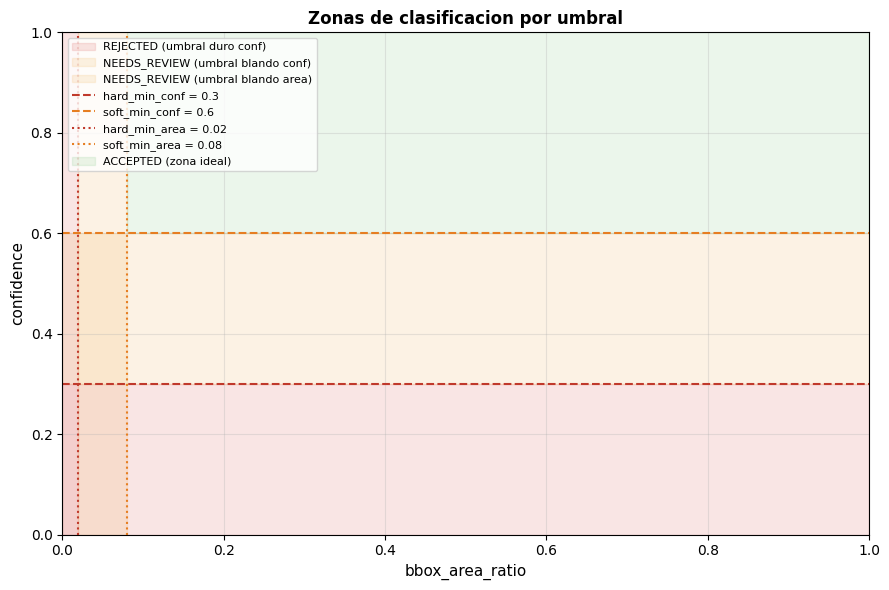

In [3]:
cfg = cropper.cfg

fig, ax = plt.subplots(figsize=(9, 6))

# Zonas de color
ax.axhspan(0,              cfg.hard_min_confidence,      xmin=0, xmax=1,
           color="#d9534f", alpha=0.15, label="REJECTED (umbral duro conf)")
ax.axhspan(cfg.hard_min_confidence, cfg.soft_min_confidence, xmin=0, xmax=1,
           color="#f0ad4e", alpha=0.15, label="NEEDS_REVIEW (umbral blando conf)")

ax.axvspan(0,              cfg.hard_min_bbox_area_ratio, ymin=0, ymax=1,
           color="#d9534f", alpha=0.15)
ax.axvspan(cfg.hard_min_bbox_area_ratio, cfg.soft_min_bbox_area_ratio, ymin=0, ymax=1,
           color="#f0ad4e", alpha=0.15, label="NEEDS_REVIEW (umbral blando area)")

# Lineas de umbral
ax.axhline(cfg.hard_min_confidence, color="#c0392b", lw=1.5, ls="--",
           label=f"hard_min_conf = {cfg.hard_min_confidence}")
ax.axhline(cfg.soft_min_confidence, color="#e67e22", lw=1.5, ls="--",
           label=f"soft_min_conf = {cfg.soft_min_confidence}")
ax.axvline(cfg.hard_min_bbox_area_ratio, color="#c0392b", lw=1.5, ls=":",
           label=f"hard_min_area = {cfg.hard_min_bbox_area_ratio}")
ax.axvline(cfg.soft_min_bbox_area_ratio, color="#e67e22", lw=1.5, ls=":",
           label=f"soft_min_area = {cfg.soft_min_bbox_area_ratio}")

# Zona ACCEPTED
ax.fill_between(
    [cfg.soft_min_bbox_area_ratio, 1.0],
    [cfg.soft_min_confidence,       cfg.soft_min_confidence],
    [1.0,                            1.0],
    color="#5cb85c", alpha=0.12, label="ACCEPTED (zona ideal)"
)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("bbox_area_ratio", fontsize=11)
ax.set_ylabel("confidence", fontsize=11)
ax.set_title("Zonas de clasificacion por umbral", fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "02_thresholds.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Prueba unitaria -- una imagen

In [5]:
RAW_DIR = PROJECT_ROOT / config["raw_data_path"]

sample_path = next(
    (f for cls_dir in sorted(RAW_DIR.iterdir()) if cls_dir.is_dir()
     for f in sorted(cls_dir.iterdir())
     if f.suffix.lower() in {".jpg", ".jpeg", ".png"}),
    None
)

if sample_path is None:
    print("No se encontraron imagenes en data/raw/.")
else:
    result = cropper.crop(sample_path)
    m      = result.metrics

    print(f"Imagen  : {sample_path.relative_to(PROJECT_ROOT)}")
    print(f"Estado  : {result.status.upper()}")
    if m:
        print(f"  confidence      : {m.confidence:.4f}")
        print(f"  bbox_area_ratio : {m.bbox_area_ratio:.4f}")
        print(f"  touches_edge    : {m.touches_edge}")
        print(f"  clipped         : {m.clipped}")
        print(f"  aspect_ratio    : {m.aspect_ratio:.4f}")
        print(f"  final_size      : {m.final_w}x{m.final_h}")
    if result.rejected:
        print(f"  rejection_reason: {result.rejection_reason}")
    if result.needs_review:
        print(f"  review_flags    : {result.review_flags}")
    print()
    print("Metadata dict:")
    import json
    print(json.dumps(result.to_metadata_dict(), indent=2, default=str))


Imagen  : data\raw\ardea-alba\ardea-alba_0013c9efa6.jpg
Estado  : NEEDS_REVIEW
  confidence      : 0.8259
  bbox_area_ratio : 0.0797
  touches_edge    : False
  clipped         : False
  aspect_ratio    : 0.9869
  final_size      : 224x224
  review_flags    : ['soft_small_bbox']

Metadata dict:
{
  "image": "ardea-alba_0013c9efa6.jpg",
  "class": "ardea-alba",
  "status": "needs_review",
  "confidence": 0.8259,
  "bbox_area_ratio": 0.0797,
  "touches_edge": false,
  "clipped": false,
  "aspect_ratio": 0.9869,
  "final_w": 224,
  "final_h": 224,
  "rejection_reason": null,
  "review_flags": "soft_small_bbox"
}


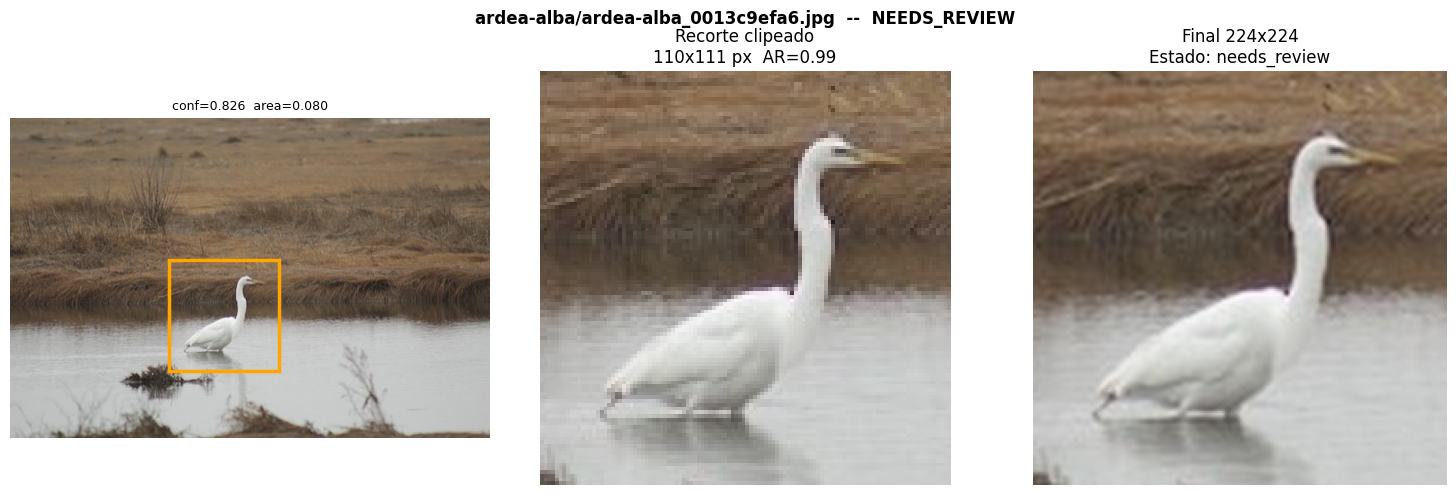

In [6]:
# Visualizacion del bbox sobre la imagen original
if sample_path and result.metrics and result.metrics.bbox_clipped:
    img_orig = Image.open(sample_path).convert("RGB")
    W, H = img_orig.size
    m = result.metrics

    # Colores por estado
    STATUS_COLOR = {
        ImageStatus.ACCEPTED:     "limegreen",
        ImageStatus.NEEDS_REVIEW: "orange",
        ImageStatus.REJECTED:     "red",
    }
    color = STATUS_COLOR.get(result.status, "gray")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"{sample_path.parent.name}/{sample_path.name}  --  {result.status.upper()}",
        fontsize=12, fontweight="bold"
    )

    # Panel 1: imagen original + bbox
    ax = axes[0]
    ax.imshow(img_orig)
    if m.bbox_clipped:
        x1,y1,x2,y2 = [int(v) for v in m.bbox_clipped]
        rect = plt.Rectangle((x1,y1), x2-x1, y2-y1,
                              edgecolor=color, facecolor="none", lw=2.5)
        ax.add_patch(rect)
    title_lines = [f"conf={m.confidence:.3f}  area={m.bbox_area_ratio:.3f}"]
    if m.touches_edge: title_lines.append("toca borde")
    if m.clipped:      title_lines.append("clipeado")
    ax.set_title("\n".join(title_lines), fontsize=9)
    ax.axis("off")

    # Panel 2: recorte crudo
    ax = axes[1]
    if m.bbox_clipped:
        x1,y1,x2,y2 = [int(v) for v in m.bbox_clipped]
        patch = img_orig.crop((x1,y1,x2,y2))
        ax.imshow(patch)
        ax.set_title(f"Recorte clipeado\n{patch.size[0]}x{patch.size[1]} px  AR={m.aspect_ratio:.2f}")
    ax.axis("off")

    # Panel 3: imagen final
    ax = axes[2]
    if result.image:
        ax.imshow(result.image)
        ax.set_title(f"Final {m.final_w}x{m.final_h}\nEstado: {result.status}")
    else:
        ax.text(0.5, 0.5, "RECHAZADA\nsin imagen", ha="center", va="center",
                fontsize=12, color="red", transform=ax.transAxes)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "logs" / "02_sample_pipeline.png",
                dpi=150, bbox_inches="tight")
    plt.show()


## 5. Procesar el dataset completo

Limpiamos la DB antes de re-procesar para evitar duplicados de ejecuciones anteriores.


In [7]:
PROCESSED_DIR = PROJECT_ROOT / config["processed_data_path"]
REVIEW_DIR    = PROJECT_ROOT / "data" / "review"

# Limpiar DB para empezar desde cero (comentar si quieres acumular)
db.clear()
print("Base de datos limpiada.")

class_dirs = sorted(d for d in RAW_DIR.iterdir() if d.is_dir())
print(f"Clases a procesar: {len(class_dirs)}\n")

all_results = []

print(f"{'Clase':<32} {'Acc':>5} {'Rev':>5} {'Rej':>5} {'Tot':>5}  Tasa OK")
print("-" * 65)

for cls_dir in class_dirs:
    stats = process_class_directory(
        class_dir    = cls_dir,
        accepted_dir = PROCESSED_DIR / cls_dir.name,
        review_dir   = REVIEW_DIR    / cls_dir.name,
        cropper      = cropper,
    )

    # Guardar metadata en batch
    records = [r.to_metadata_dict() for r in stats["results"]]
    db.insert_batch(records)
    all_results.extend(stats["results"])

    acc  = stats["accepted"]
    rev  = stats["needs_review"]
    rej  = stats["rejected"]
    tot  = stats["total"]
    pct  = (acc + rev) / tot * 100 if tot else 0
    print(f"{cls_dir.name:<32} {acc:>5} {rev:>5} {rej:>5} {tot:>5}  {pct:.0f}%")

print("-" * 65)
total_acc = sum(1 for r in all_results if r.accepted)
total_rev = sum(1 for r in all_results if r.needs_review)
total_rej = sum(1 for r in all_results if r.rejected)
total_all = len(all_results)
print(f"{'TOTAL':<32} {total_acc:>5} {total_rev:>5} {total_rej:>5} {total_all:>5}")
print(f"\nRegistros en DB: {db.count()}")


Base de datos limpiada.
Clases a procesar: 16

Clase                              Acc   Rev   Rej   Tot  Tasa OK
-----------------------------------------------------------------
ardea-alba                         251   377   182   810  78%
atlapetes-latinuchus               170   279    88   537  84%
butorides-striata                  220   248    70   538  87%
chlorochrysa-nitidissima           292   332    60   684  91%
colibri-coruscans                  198   408   107   713  85%
gallinula-galeata                  230   320   199   749  73%
metallura-tyrianthina              219   302   108   629  83%
momotus-aequatorialis              204   558    75   837  91%
phimosus-infuscatus                280   359   164   803  80%
piaya-cayana                       105   336   188   629  70%
pitangus-sulphuratus               271   329   118   718  84%
ramphastos-ambiguus                204   455   382  1041  63%
sicalis-flaveola                   283   341   154   778  80%
thraupis-episco

## 6. Resumen estadistico desde la base de datos

In [8]:
summary = db.summary()

print(f"Total imagenes procesadas : {summary['total']}")
print()

# Por estado
print("Por estado:")
for status, n in sorted(summary["by_status"].items()):
    pct = n / summary["total"] * 100 if summary["total"] else 0
    bar = "#" * int(pct / 2)
    print(f"  {status:<14} {n:>5}  ({pct:5.1f}%)  {bar}")

print()
print(f"Confianza media         : {summary['avg_confidence']:.4f}")
print(f"Area bbox media         : {summary['avg_bbox_area_ratio']:.4f}")


Total imagenes procesadas : 11586

Por estado:
  accepted        3720  ( 32.1%)  ################
  needs_review    5658  ( 48.8%)  ########################
  rejected        2208  ( 19.1%)  #########

Confianza media         : 0.7550
Area bbox media         : 0.3645


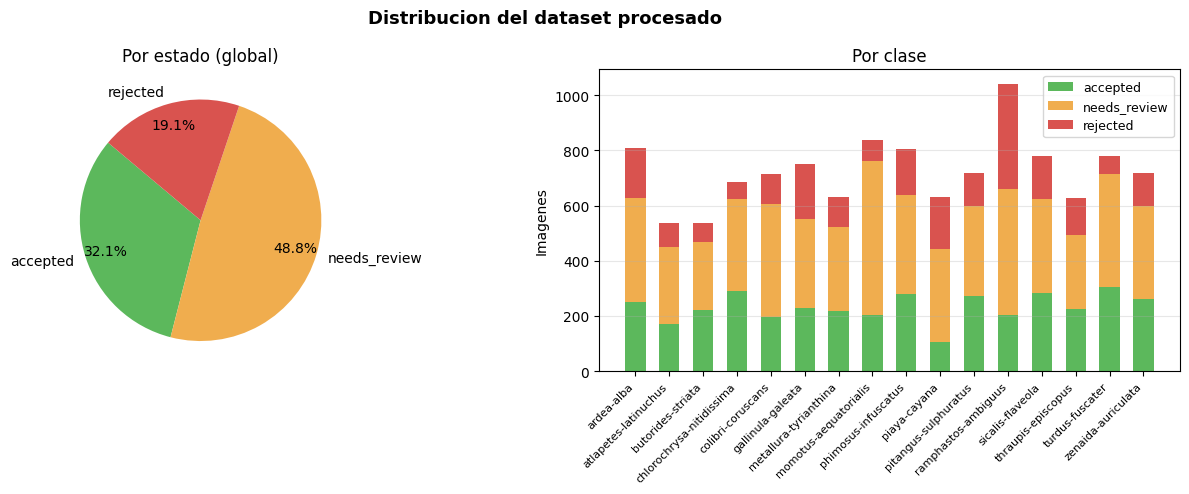

In [9]:
# Grafica de distribucion por estado
status_data = summary["by_status"]
labels  = list(status_data.keys())
values  = list(status_data.values())
palette = {"accepted": "#5cb85c", "needs_review": "#f0ad4e", "rejected": "#d9534f"}
colors  = [palette.get(l, "#aaaaaa") for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribucion del dataset procesado", fontsize=13, fontweight="bold")

# Torta
axes[0].pie(values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=140, pctdistance=0.82)
axes[0].set_title("Por estado (global)")

# Barras apiladas por clase
classes_sorted = sorted(summary["by_class"].keys())
acc_vals  = [summary["by_class"][c].get("accepted",     0) for c in classes_sorted]
rev_vals  = [summary["by_class"][c].get("needs_review", 0) for c in classes_sorted]
rej_vals  = [summary["by_class"][c].get("rejected",     0) for c in classes_sorted]

x = np.arange(len(classes_sorted))
w = 0.6
axes[1].bar(x, acc_vals,  w, label="accepted",     color="#5cb85c")
axes[1].bar(x, rev_vals,  w, label="needs_review", color="#f0ad4e",
            bottom=acc_vals)
axes[1].bar(x, rej_vals,  w, label="rejected",     color="#d9534f",
            bottom=[a+r for a,r in zip(acc_vals, rev_vals)])
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Imagenes"); axes[1].set_title("Por clase")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "02_status_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()


## 7. Analisis de flags de needs_review

Cada imagen en needs_review tiene uno o mas flags. Ver cuales son los mas
frecuentes ayuda a ajustar los umbrales del pipeline.


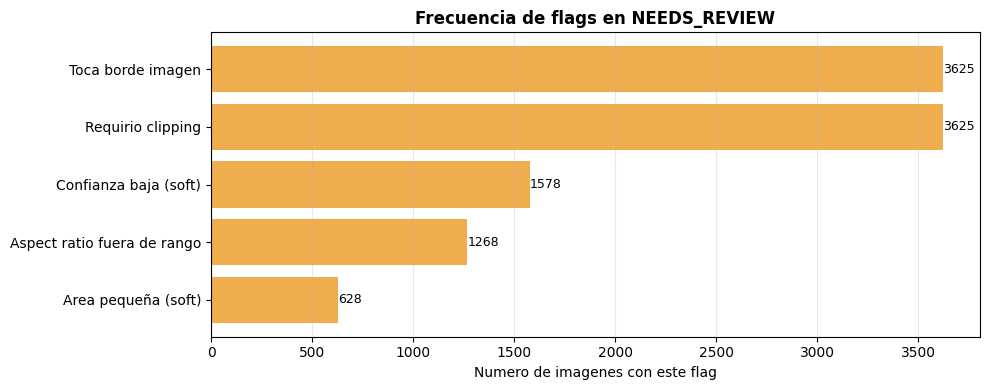

Nota: una imagen puede tener multiples flags.
Total imagenes en needs_review: 5658
  Toca borde imagen                    3625  (64.1%)
  Requirio clipping                    3625  (64.1%)
  Confianza baja (soft)                1578  (27.9%)
  Aspect ratio fuera de rango          1268  (22.4%)
  Area pequeña (soft)                   628  (11.1%)


In [10]:
FLAG_LABELS = {
    "soft_low_confidence":    "Confianza baja (soft)",
    "soft_small_bbox":        "Area pequeña (soft)",
    "touches_image_edge":     "Toca borde imagen",
    "aspect_ratio_out_of_range": "Aspect ratio fuera de rango",
    "bbox_required_clipping": "Requirio clipping",
    "final_image_too_small":  "Imagen final muy pequeña",
}

flag_counts = summary["review_flag_counts"]
if not flag_counts:
    print("No hay imagenes en needs_review.")
else:
    sorted_flags = sorted(flag_counts.items(), key=lambda x: x[1], reverse=True)
    labels_f = [FLAG_LABELS.get(k, k) for k, _ in sorted_flags]
    values_f = [v for _, v in sorted_flags]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(labels_f[::-1], values_f[::-1], color="#f0ad4e")
    for bar, val in zip(bars, values_f[::-1]):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9)
    ax.set_xlabel("Numero de imagenes con este flag")
    ax.set_title("Frecuencia de flags en NEEDS_REVIEW", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "logs" / "02_review_flags.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("Nota: una imagen puede tener multiples flags.")
    total_review = summary["by_status"].get("needs_review", 0)
    print(f"Total imagenes en needs_review: {total_review}")
    for k, v in sorted_flags:
        label = FLAG_LABELS.get(k, k)
        pct   = v / total_review * 100 if total_review else 0
        print(f"  {label:<35} {v:>5}  ({pct:.1f}%)")


## 8. Galeria de imagenes rechazadas (REJECTED)

Una fila por cada razon de rechazo duro. Permite auditar visualmente
si los umbrales son demasiado estrictos o insuficientes.


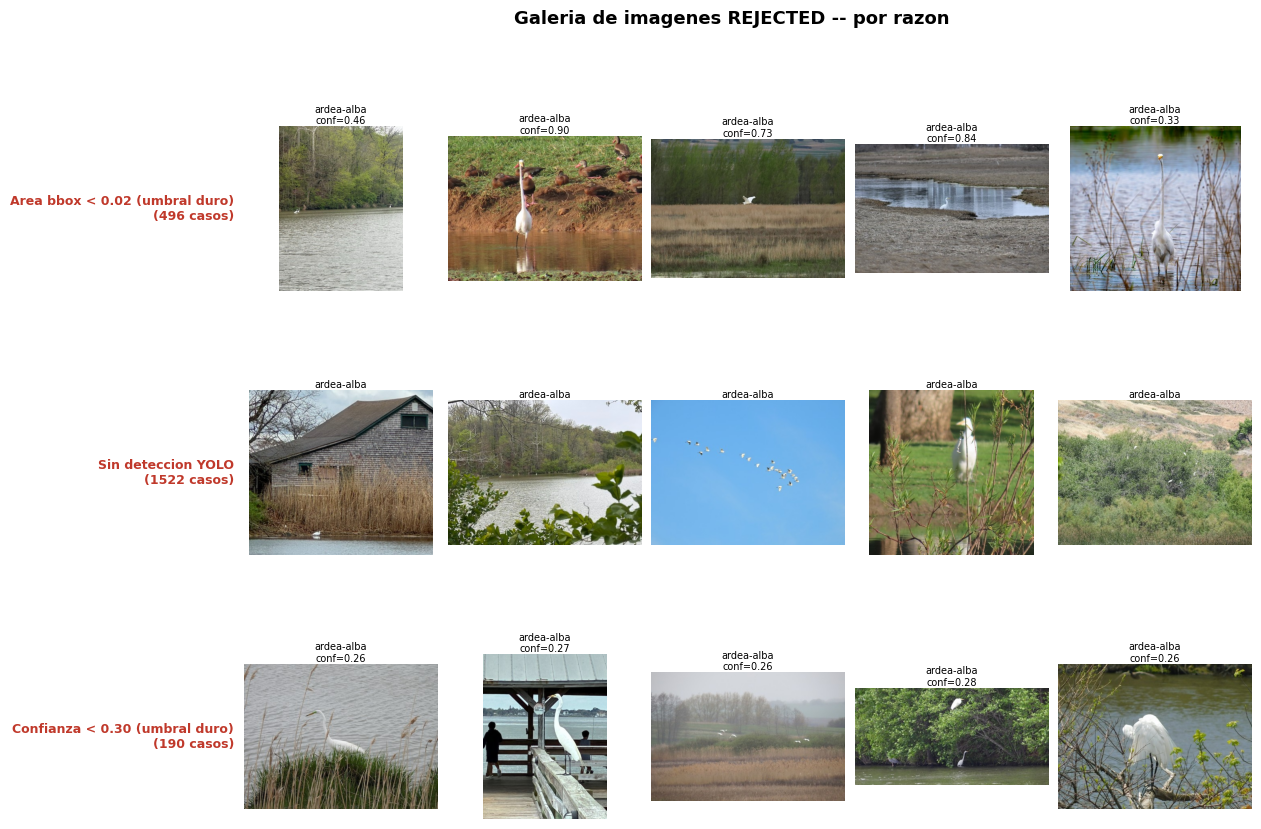

In [11]:
REJECTION_LABELS = {
    "no_detection":          "Sin deteccion YOLO",
    "hard_low_confidence":   "Confianza < 0.30 (umbral duro)",
    "hard_small_bbox":       "Area bbox < 0.02 (umbral duro)",
    "bbox_empty_after_clip": "Bbox vacio tras clip",
    "load_error":            "Error al cargar imagen",
}

rejected_records = db.query_by_status("rejected")

def show_gallery(records: list, group_key: str, label_map: dict,
                 title: str, max_per_group: int = 5, save_name: str = None):
    """Galeria de imagenes agrupada por una clave de metadata."""
    if not records:
        print("Sin registros para mostrar.")
        return

    groups = defaultdict(list)
    for r in records:
        groups[r.get(group_key, "desconocido")].append(r)

    n_groups = len(groups)
    fig = plt.figure(figsize=(max_per_group * 2.6, n_groups * 3.0))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    outer = gridspec.GridSpec(n_groups, 1, figure=fig, hspace=0.6)

    for row_idx, (group_val, items) in enumerate(groups.items()):
        group_label = label_map.get(group_val, group_val)
        sample = items[:max_per_group]

        inner = gridspec.GridSpecFromSubplotSpec(
            1, max_per_group, subplot_spec=outer[row_idx], wspace=0.05
        )
        ax_label = fig.add_subplot(outer[row_idx])
        ax_label.set_axis_off()
        ax_label.text(
            -0.01, 0.5,
            f"{group_label}\n({len(items)} casos)",
            transform=ax_label.transAxes,
            va="center", ha="right", fontsize=9, fontweight="bold",
            color="#c0392b",
        )

        for col_idx in range(max_per_group):
            ax = fig.add_subplot(inner[col_idx])
            ax.set_axis_off()
            if col_idx >= len(sample):
                continue
            rec = sample[col_idx]
            # Reconstruir ruta de la imagen original
            img_path = RAW_DIR / (rec.get("class") or "") / (rec.get("image") or "")
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                conf = rec.get("confidence")
                conf_str = f"\nconf={conf:.2f}" if conf else ""
                ax.set_title(f"{(rec.get('class') or '')[:18]}{conf_str}",
                             fontsize=7, pad=2)
            except Exception:
                ax.text(0.5, 0.5, "N/D", ha="center", va="center",
                        fontsize=8, color="gray", transform=ax.transAxes)

    if save_name:
        plt.savefig(PROJECT_ROOT / "logs" / save_name,
                    dpi=120, bbox_inches="tight")
    plt.show()


show_gallery(
    records       = rejected_records,
    group_key     = "rejection_reason",
    label_map     = REJECTION_LABELS,
    title         = "Galeria de imagenes REJECTED -- por razon",
    max_per_group = 5,
    save_name     = "02_rejected_gallery.png",
)


## 9. Galeria de imagenes NEEDS_REVIEW

Muestra muestras de imagenes dudosas agrupadas por el primer flag asignado.
Estas imagenes estan guardadas en `data/review/` para inspeccion manual.


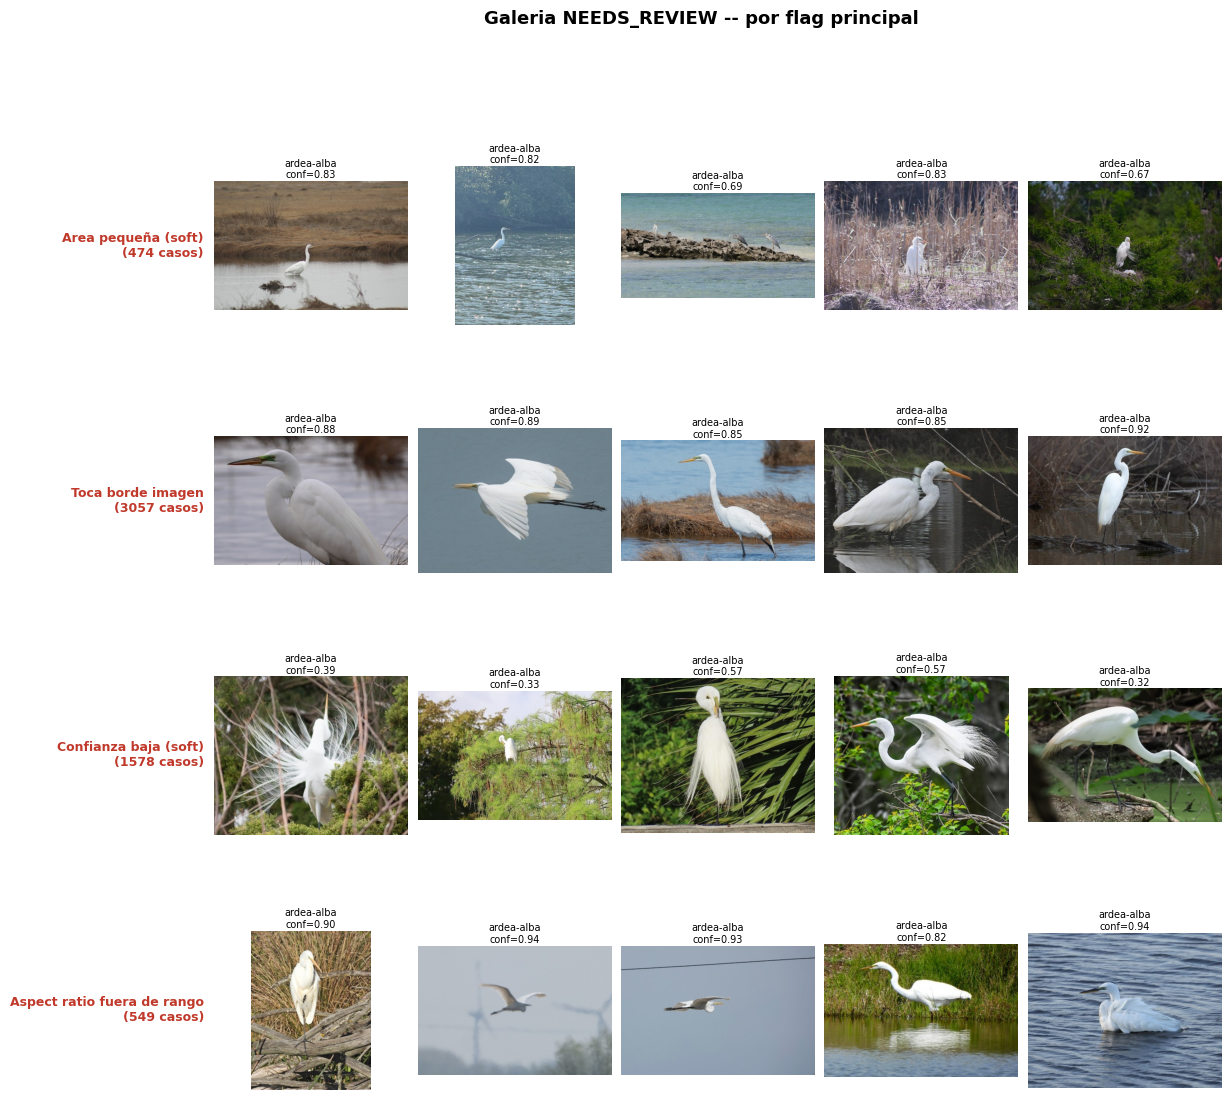

In [12]:
review_records = db.query_by_status("needs_review")

# Para la galeria, agrupar por el primer flag
def first_flag(r: dict) -> str:
    flags = r.get("review_flags") or ""
    return flags.split(",")[0].strip() if flags else "sin_flag"

# Crear registros con campo auxiliar
review_with_first_flag = [
    {**r, "_first_flag": first_flag(r)} for r in review_records
]

show_gallery(
    records       = review_with_first_flag,
    group_key     = "_first_flag",
    label_map     = FLAG_LABELS,
    title         = "Galeria NEEDS_REVIEW -- por flag principal",
    max_per_group = 5,
    save_name     = "02_review_gallery.png",
)


## 10. Consultas de ejemplo sobre la DB

`MetadataDB` expone metodos de consulta directos.
Tambien puedes usar SQL crudo con cualquier cliente SQLite.


In [13]:
import json

# a) Imagenes que tocan borde Y tienen baja confianza
touching_low = db.query_by_flag("touches_image_edge")
touching_low_conf = [r for r in touching_low if (r["confidence"] or 1) < 0.55]
print(f"Imagenes que tocan borde con conf < 0.55: {len(touching_low_conf)}")
if touching_low_conf:
    print(json.dumps(touching_low_conf[0], indent=2, default=str))

print()

# b) Clase con mayor tasa de rechazo
by_class = summary["by_class"]
reject_rate = {
    cls: (data.get("rejected", 0) / sum(data.values()) * 100)
    for cls, data in by_class.items()
    if sum(data.values()) > 0
}
worst_class = max(reject_rate, key=reject_rate.get) if reject_rate else None
if worst_class:
    print(f"Clase con mayor tasa de rechazo: {worst_class} ({reject_rate[worst_class]:.1f}%)")
    print(f"  Detalle: {dict(by_class[worst_class])}")


Imagenes que tocan borde con conf < 0.55: 413
{
  "id": 9406,
  "image": "ardea-alba_03a5582af5.jpg",
  "class": "ardea-alba",
  "status": "needs_review",
  "confidence": 0.3873,
  "bbox_area_ratio": 0.3397,
  "touches_edge": 1,
  "clipped": 1,
  "aspect_ratio": 0.5437,
  "final_w": 224,
  "final_h": 224,
  "rejection_reason": null,
  "review_flags": "soft_low_confidence,touches_image_edge,bbox_required_clipping",
  "processed_at": "2026-04-21T01:45:38.655839+00:00"
}

Clase con mayor tasa de rechazo: ramphastos-ambiguus (36.7%)
  Detalle: {'accepted': 204, 'needs_review': 455, 'rejected': 382}


In [14]:
# Ejemplo de registro JSON completo (como aparece en la DB)
print("Ejemplo de registro en metadata.sqlite:")
print()
sample_record = (
    db.query_by_status("accepted")     or
    db.query_by_status("needs_review") or
    db.query_by_status("rejected")
)
if sample_record:
    # Mostrar solo los campos del spec original del proyecto
    r = sample_record[0]
    spec = {
        "image":          r["image"],
        "status":         r["status"],
        "confidence":     r["confidence"],
        "bbox_area_ratio":r["bbox_area_ratio"],
        "touches_edge":   bool(r["touches_edge"]) if r["touches_edge"] is not None else None,
        "clipped":        bool(r["clipped"])      if r["clipped"]      is not None else None,
    }
    print(json.dumps(spec, indent=2, default=str))


Ejemplo de registro en metadata.sqlite:

{
  "image": "ardea-alba_00a1577fd1.jpg",
  "status": "accepted",
  "confidence": 0.8938,
  "bbox_area_ratio": 0.1811,
  "touches_edge": false,
  "clipped": false
}


## 11. Resumen final

In [15]:
summary = db.summary()   # refrescar

total  = summary["total"]
acc    = summary["by_status"].get("accepted",     0)
rev    = summary["by_status"].get("needs_review", 0)
rej    = summary["by_status"].get("rejected",     0)

print("=" * 52)
print("  RESUMEN PREPROCESAMIENTO -- W&F BirdLab")
print("=" * 52)
print(f"  Total procesadas   : {total}")
print(f"  ACCEPTED           : {acc:>5}  ({acc/total*100:.1f}%)")
print(f"  NEEDS_REVIEW       : {rev:>5}  ({rev/total*100:.1f}%)")
print(f"  REJECTED           : {rej:>5}  ({rej/total*100:.1f}%)")
print(f"  Confianza media    : {summary['avg_confidence']:.4f}")
print(f"  Area bbox media    : {summary['avg_bbox_area_ratio']:.4f}")
print(f"  DB path            : {DB_PATH}")
print("=" * 52)
print()
print("Siguiente paso --> notebooks/03_split.ipynb")
print("  Las imagenes ACCEPTED en data/processed/ entran al split.")
print("  Las NEEDS_REVIEW en data/review/ requieren inspeccion manual.")


  RESUMEN PREPROCESAMIENTO -- W&F BirdLab
  Total procesadas   : 11586
  ACCEPTED           :  3720  (32.1%)
  NEEDS_REVIEW       :  5658  (48.8%)
  REJECTED           :  2208  (19.1%)
  Confianza media    : 0.7550
  Area bbox media    : 0.3645
  DB path            : D:\desarrollo\bird-lab\metadata\metadata.sqlite

Siguiente paso --> notebooks/03_split.ipynb
  Las imagenes ACCEPTED en data/processed/ entran al split.
  Las NEEDS_REVIEW en data/review/ requieren inspeccion manual.
